# LIBRARIES

In [42]:
import tarfile
import os
import pandas as pd
from pathlib import Path
import numpy as np
from collections import Counter
from typing import Sequence, Union
import torch
from monai.networks.nets import UNet
from monai.losses import DiceCELoss


import nibabel as nib
from nibabel.funcs import as_closest_canonical

from monai.transforms import *
from monai.data import Dataset, DataLoader
from monai.data.meta_tensor import MetaTensor

from matplotlib import pyplot as plt

DATA_DIR = Path(r"C:\Users\dibmir\dslab_med\data\pw\xdata\ATLAS3_Training_Raw")
#) KEY = "bLw,A>?jJ6j6KnV"
NUM_EPOCHS = 30

# FUNCTIONS

In [3]:
def t1_masks_path_extractor(
    data_dir: Path
    ) -> tuple[list[str], list[str]]:


    image_paths = []
    mask_paths = []

    for t1_file in data_dir.rglob("*T1w.nii.gz"):
        mask_file = next(
            t1_file.parent.glob("*lesion_mask.nii.gz"),
            None
        )

        if mask_file is not None:
            image_paths.append(str(t1_file))
            mask_paths.append(str(mask_file))

    if len(image_paths) > 0 and len(mask_paths) > 0:
        print("'image paths' and 'mask paths' lists properly created")

        if len(image_paths) != len(mask_paths):
            print("Warning: different number between images and masks")

    else:
        print("No file was found!")

    return image_paths, mask_paths

        

In [4]:
def reorder_imgs_to_canonical_space(
    *,
    image_paths: Sequence[str],
    mask_paths: Sequence[str],
) -> tuple[list[nib.nifti1.Nifti1Image], 
           list[nib.nifti1.Nifti1Image]]:
    
    images = []
    masks = []

    for img_path, msk_path in zip(image_paths, mask_paths):

        img = nib.load(img_path)
        msk = nib.load(msk_path)

        if nib.aff2axcodes(img.affine) != ("R", "A", "S"):
            img = nib.as_closest_canonical(img)

        if nib.aff2axcodes(msk.affine) != ("R", "A", "S"):
            msk = nib.as_closest_canonical(msk)

        images.append(img)
        masks.append(msk)

    return images, masks

In [5]:
def plot_orient_distr(image_paths: Sequence[str]):
    
    affine_lst = []
    for path in image_paths:
        affine_lst.append(nib.aff2axcodes(nib.load(path).affine))

    counts = Counter(affine_lst)
    counts = pd.Series(affine_lst).value_counts()

    counts.plot(kind='bar')

    plt.xlabel("Orientation")
    plt.ylabel("Number of brain volumes")
    plt.title("MRI orientation distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()   

In [6]:
def zscore_nonzero(
    img: nib.Nifti1Image
    ) -> nib.Nifti1Image:
    
    img = img.astype(np.float32, copy=False)

    mask = img > 0
    m = img[mask].mean()
    s = img[mask].std()

    img[mask] -= m
    img[mask] /= (s + 1e-8)

    return img

In [7]:
def check_shape_match(img: nib.Nifti1Image, 
                      mask: nib.Nifti1Image):
    return img.shape == mask.shape

In [8]:
def shape_mismatch_indeces(images: Sequence[nib.Nifti1Image],
                           masks: Sequence[nib.Nifti1Image]):

    idx_list = []
    for i in range(len(images)-1):
        if not check_shape_match(images[i], masks[i]):
            print(f"la coppia img/mask di indice {i} ha shape diverse:\n img shape: {images[i].shape} \t mask shape: {masks[i].shape}")
            idx_list.append(i)
    return idx_list

In [9]:
def show_overlay(
    t1ImmData: Union[np.ndarray, MetaTensor],
    maskData: Union[np.ndarray, MetaTensor],
    slice_idx=None
):

    if slice_idx is None:
        slice_idx = t1ImmData.shape[2] // 2

    plt.figure(figsize=(6,6))

    plt.imshow(t1ImmData[:,slice_idx,:], cmap='Greys_r', origin="lower")
    plt.imshow(maskData[:,slice_idx,:], cmap="autumn", alpha=0.5, origin="lower")

    plt.title("T1 + Lesion overlay")
    plt.axis("off")
    plt.show()

In [10]:
# with tarfile.open(os.path.join(DATA_DIR, "ATLAS_R3.0_raw.tar.gz"), "r:gz") as tar:
#     tar.extractall(os.path.join(DATA_DIR, "xdata/"))

# DATA READING & PREP

## EDA

### Paths reading

In [11]:
image_paths, mask_paths = t1_masks_path_extractor(data_dir=DATA_DIR)

'image paths' and 'mask paths' lists properly created


### Images orientation distribution

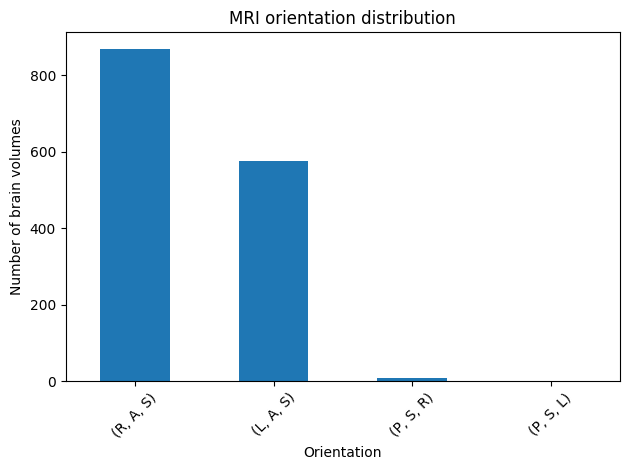

In [12]:
plot_orient_distr(image_paths=image_paths)

### Reorder to R.A.S.

In [13]:
"""
images, masks = reorder_imgs_to_canonical_space(image_paths=image_paths,
                                                mask_paths=mask_paths)
"""

'\nimages, masks = reorder_imgs_to_canonical_space(image_paths=image_paths,\n                                                mask_paths=mask_paths)\n'

### Reorder mask2img shape dim

In [14]:
"""
idxMism =  shape_mismatch_indeces(images, masks)
for idx in idxMism:
    dataT = np.transpose(masks[idx].get_fdata(), (0, 2, 1))
    masks[idx] = nib.Nifti1Image(dataT, 
                                 affine=masks[idx].affine,
                                 header=masks[idx].header)
"""

'\nidxMism =  shape_mismatch_indeces(images, masks)\nfor idx in idxMism:\n    dataT = np.transpose(masks[idx].get_fdata(), (0, 2, 1))\n    masks[idx] = nib.Nifti1Image(dataT, \n                                 affine=masks[idx].affine,\n                                 header=masks[idx].header)\n'

### Check for anisotropy

In [15]:
zooms = np.array([
    nib.load(p).header.get_zooms()[:3]
    for p in image_paths
])

df = pd.DataFrame(zooms, columns=["sx", "sy", "sz"])
print(df.describe())
print(df.quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

                sx           sy           sz
count  1453.000000  1453.000000  1453.000000
mean      0.967674     0.989333     0.998816
std       0.206960     0.381273     0.550597
min       0.464015     0.250749     0.250749
25%       0.999901     1.000000     1.000000
50%       1.000000     1.000000     1.000000
75%       1.000000     1.000000     1.000000
max       5.999997     3.000000     6.199999
            sx        sy        sz
0.01  0.499992  0.436893  0.436893
0.05  0.500002  0.474894  0.474894
0.50  1.000000  1.000000  1.000000
0.95  1.100000  1.302083  1.026786
0.99  1.500000  3.000000  3.536071


In [16]:
tol = 0.2

is_isotropic = np.all(np.isclose(zooms, 1.0, atol=tol), axis=1)

count = np.sum(is_isotropic)
total = len(zooms)

print(f"{count} / {total} isotrope images (1.0,1.0,1.0)")
print(f"Percent: {count/total:.2%}")

1180 / 1453 isotrope images (1.0,1.0,1.0)
Percent: 81.21%


In [17]:
anisotropy = zooms.max(axis=1) / zooms.min(axis=1)
threshold = 1.5
outliers = np.where(anisotropy > threshold)[0]

print(f"Immagini fortemente anisotrope: {len(outliers)} / {len(zooms)}")
print("Esempi:")
print(zooms[outliers[:10]])

Immagini fortemente anisotrope: 136 / 1453
Esempi:
[[0.50000376 0.2507493  0.2507493 ]
 [0.4791666  0.4791667  5.9999976 ]
 [0.4999991  0.25074923 0.25074932]
 [0.8918047  0.89180475 6.        ]
 [0.89843744 0.8984375  6.0000014 ]
 [0.46874997 0.46874997 6.000004  ]
 [0.89843744 0.89843744 6.199999  ]
 [0.46875003 0.46875003 5.9999957 ]
 [0.7575758  0.7575758  6.000007  ]
 [0.50000197 0.25074926 0.25074923]]


* Since the major part of the images are in a voxel space around (1.0, 1.0, 1.0), with a range of deviation of 0.5, there are cases in which a strong anisotropy is registered.
* In particular, in 136 out of 1453 a max/min ratio of the voxel axes over 1.5 is revealed.

## MONAI pipeline

In [18]:
def preprocessingPipeline(image_paths: Sequence[str],
                       mask_paths: Sequence[str]
                       ) -> Dataset:
    batch_files = [
        {"image": img, "label": msk}
        for img, msk in zip(image_paths, mask_paths)
    ]

    batch_transforms = Compose([
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]), # add 1 channel at the beginning of the tensor
        Orientationd(keys=["image", "label"], axcodes="RAS"), # reorient to RAS

        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest")
        ), # resample voxel to arrange space in (1.0, 1.0, 1.0)

        CropForegroundd(
            keys=["image", "label"],
            source_key="image",
            margin=10
        ), # remove foreground
        NormalizeIntensityd(keys=["image"], 
                            nonzero=True), # normalize also nonzero voxels

        CenterSpatialCropd( # crop part of non central brain regions
            keys=["image", "label"],
            roi_size=(128, 128, 64)
        ),
        EnsureTyped(keys=["image", "label"])
    ])
    
    return Dataset(
        data=batch_files,
        transform=batch_transforms
    )

### Data loader

In [19]:
train_loader = DataLoader(
    dataset=preprocessingPipeline(image_paths=image_paths, 
                                  mask_paths=mask_paths),
    batch_size=2,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

In [29]:
batch = next(iter(train_loader))

In [30]:
images = batch["image"]
labels = batch["label"]

In [36]:
labels[0].shape

torch.Size([1, 128, 128, 64])

Spacingd:
* **bilinear** interpolation is used for t1 images: resample is run by averaging continous voxels. For instance, to enlarge (1.0 , 2.0) into 3 voxels, it is obtained (1.0, 1.5, 2.0)
* **nearest** interpolation is used for masks: in this case, as mask takes into account binary integers, enlarging the voxel space is performed by chosing the nearest value. For instance to enlarge to the right (0,1) -> (0,1,1)

CropForeground:
* remove out-of-interest voxels, when black frame is large enough. It results in a zoomed-like brain image

NormalizeIntensityd:
* scale voxel values based on mean and std (`subtrahend=None`)
* `nonzero=True` applies normalization by considering nonzero voxels as well, with the result of obtaining lightened frame
* `channel_wise=True` applies normalization by computing mean/std for each single channel separately. Otherwise, global mean/std would be computed with the result of a global normalization. In my case, having a single channel, this param is irrelevant.


In [87]:
# print(nib.load(image_paths[0]).shape)
imm_norm = dataset[0]['image'].squeeze(0)
imm = nib.load(image_paths[0]).get_fdata()

In [88]:
print(f"img voxel min value before normalization: {imm.min()}\t")
print(f"img voxel max value before normalization: {imm.max()}\t")
print(f"img voxel min value after normalization: {imm_norm.min()}\t")
print(f"img voxel max value after normalization: {imm_norm.max()}\t")

img voxel min value before normalization: 0.0	
img voxel max value before normalization: 2210.2221335470676	
img voxel min value after normalization: 0.0	
img voxel max value after normalization: 2107.00830078125	


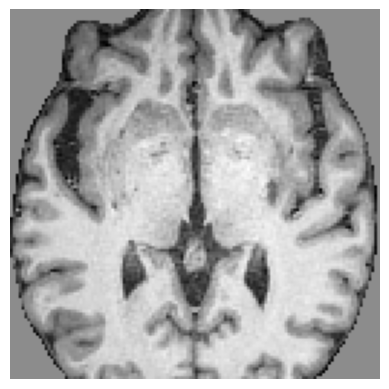

In [41]:
imm = images[0].squeeze(0)
plt.imshow(np.flip(imm[:,:,imm.shape[2]//2]).T, cmap='Greys_r')
plt.axis('off')
plt.show()

In [ ]:
"""
print(f"image[0] shape before EnsureChannelFirstd: {nib.load(image_paths[0]).shape}")
print(f"image[0] shape after EnsureChannelFirstd: {dataset[0]['image'].shape}")
print(f"orig orientation: {nib.aff2axcodes(nib.load(image_paths[8]).affine)}")
print(f"orientation after Orientationd: {nib.aff2axcodes(dataset[8]['image'].affine)}")
print(f"orig voxel space: {nib.load(image_paths[0]).header.get_zooms()}")
print(f"voxel space after Spacingd: {dataset[0]['image'].pixdim}")
"""

NameError: name 'nib' is not defined

* provare scaling su singolo volume, e visualizzare
* provare il voxel spacing di monai su singolo volume e vedere come esce

### Net Architecture

#### net settings

In [47]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,  # oppure 1 se binary sigmoid
    channels=(16, 32, 64, 128, 256), # feature maps = 16
    strides=(2, 2, 2, 2),
    num_res_units=2
)

loss_fn = DiceCELoss(sigmoid=True)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

#### training loop

In [44]:
NUM_EPOCHS = 30

In [48]:
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        images = batch["image"]
        labels = batch["label"]

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch}, loss: {epoch_loss:.4f}")

KeyboardInterrupt: 

#### evaluation

In [ ]:
with torch.no_grad():
    for batch in val_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)

        dice_metric(outputs, labels)

print(dice_metric.aggregate().item())
dice_metric.reset()